# PRCP-1016-HeartDieseasePred

# Step. 1 Problem definition
Logistic Regression

The objective of this project is to build a machine learning model that predicts whether a patient has heart disease or not based on medical attributes 
such as age, cholesterol level, blood pressure, chest pain type, heart rate, and ECG results.

This is a Binary Classification problem where:

* 0 represents no heart disease
* 1 represents presence of heart disease

The dataset contains patient health records collected from cardiovascular studies. The project uses values.csv as input features and labels.csv as the 
target dataset, merged using patient_id.

This project is important because early prediction of heart disease can help doctors make faster and better medical decisions, reduce health risks, and 
improve patient care.

For this project, Logistic Regression is used as the machine learning algorithm because it is simple, effective, and suitable for binary classification 
problems.

### Types of machine learning problem

 Category              | Type                  
 --------------------- | --------------------- 
 Machine Learning Type | Supervised Learning   
 Problem Type          | Classification        
 Classification Type   | Binary Classification 

#### Columns and its meaning according to me for this HeartDiseasePred project.

| Column Name                          | Meaning                                               |
| ------------------------------------ | ----------------------------------------------------- |
| patient_id                           | Unique ID of each patient                             |
| slope_of_peak_exercise_st_segment    | Slope of peak exercise ST segment from ECG            |
| thal                                 | Thallium stress test result                           |
| resting_blood_pressure               | Resting blood pressure                                |
| chest_pain_type                      | Type of chest pain                                    |
| num_major_vessels                    | Number of major blood vessels                         |
| fasting_blood_sugar_gt_120_mg_per_dl | Whether fasting blood sugar is greater than 120 mg/dl |
| resting_ekg_results                  | Resting electrocardiographic results                  |
| serum_cholesterol_mg_per_dl          | Cholesterol level in blood                            |
| oldpeak_eq_st_depression             | ST depression induced by exercise                     |
| sex                                  | Gender of patient (0 = Female, 1 = Male)              |
| age                                  | Age of patient                                        |
| max_heart_rate_achieved              | Maximum heart rate achieved                           |
| exercise_induced_angina              | Exercise-induced chest pain                           |
| heart_disease_present                | Target variable (0 = No disease, 1 = Disease present) |


# Step. 2 Data collection
The dataset used in this project is taken from the DrivenData heart disease prediction competition.
The dataset contains patient medical records and cardiovascular health information used to predict the presence of heart disease.

Two CSV files are used in this project:


* values.csv → contains input features such as age, blood pressure, cholesterol, chest pain type, ECG results, and heart rate.


* labels.csv → contains the target variable heart_disease_present.


Both datasets are merged using the patient_id column to create the final dataset for model training and prediction.

In [28]:
#Import Libraries

import pandas as pd               # Used for data manipulation and analysis.
import numpy as np                # Used for numerical operations and arrays.
import seaborn as sns             # Used for data visualization and statistical plots.
import matplotlib.pyplot as plt   # Used for creating graphs and charts.
import sklearn                    # Used for machine learning models and preprocessing.
%matplotlib inline                

In [29]:
# Import CSV's

values_df = pd.read_csv("values.csv")
labels_df = pd.read_csv("labels.csv")

In [30]:
values_df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [31]:
labels_df

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0
...,...,...
175,5qfar3,1
176,2s2b1f,1
177,nsd00i,1
178,0xw93k,0


In [32]:
# Here, I am going to merge both datasets (values.csv (values_df) + labels.csv (labels_df

df = pd.merge(values_df, labels_df, on='patient_id')

In [33]:
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


### Basic checks

In [34]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [35]:
df.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [36]:
df.shape

(180, 15)

In [37]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [39]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


# Step. 3 Data preprocessing
In this step, the dataset is cleaned and prepared for machine learning model training.Data preprocessing helps improve data quality and model performance.
* checking dataset shape and information,
* checking missing values,
* checking duplicate records,
* handling categorical variables,
  and preparing the final dataset for model building.

In [40]:
# check missing values

df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [41]:
# Checking duplicate values - present or not

df.duplicated().sum()

np.int64(0)

In [42]:
# check categorical columns

df.select_dtypes(include='object').columns

Index(['patient_id', 'thal'], dtype='object')

In [43]:
# convert categorical column into numerical

df = pd.get_dummies(df, columns=['thal'], drop_first=True)

In [44]:
#drop unnecessary columns

df.drop('patient_id', axis=1, inplace=True)

# EDA 
Exploratory Data Analysis is performed to understand the dataset, identify patterns, analyze relationships between variables, and visualize the data
before model training.

EDA helps in:
* understanding feature distributions,
* detecting outliers,
* analyzing correlations,
* and gaining insights from the dataset.

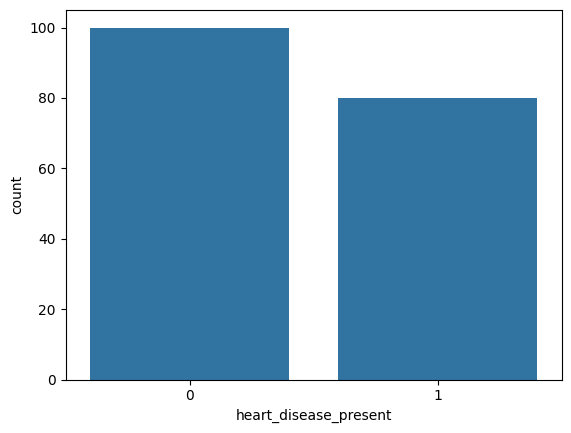

In [46]:
# Check target variable distribution

sns.countplot(x='heart_disease_present', data=df)
plt.show()

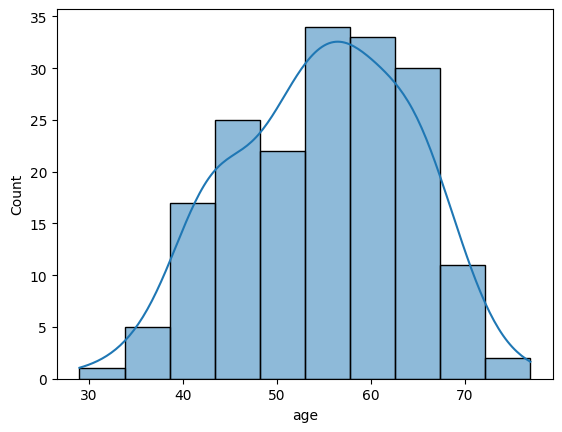

In [48]:
# Age distribution

sns.histplot(df['age'], kde=True)
plt.show()

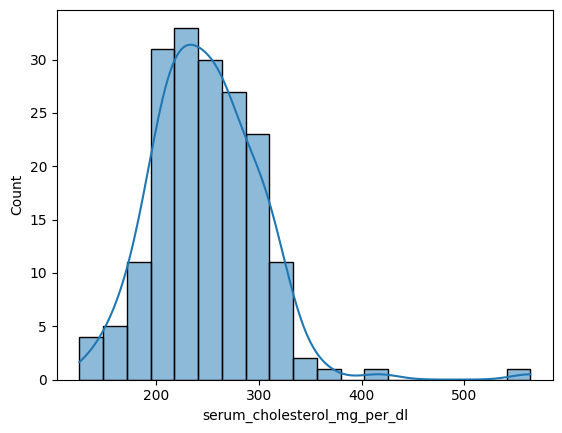

In [49]:
# Cholestral distribution

sns.histplot(df['serum_cholesterol_mg_per_dl'], kde=True)
plt.show()

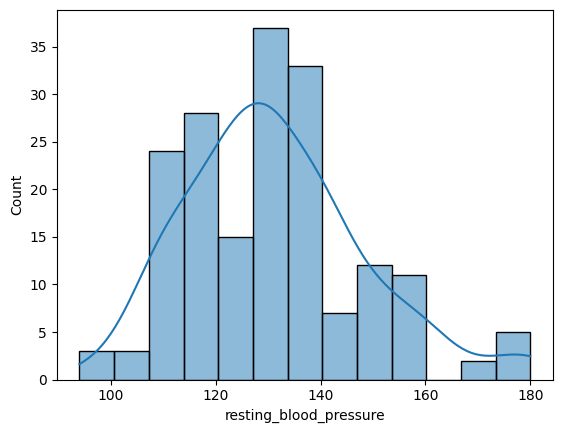

In [50]:
# Blood pressure distribution

sns.histplot(df['resting_blood_pressure'], kde=True)
plt.show()

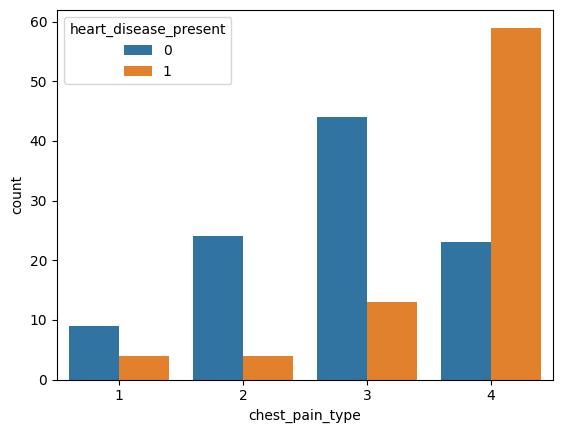

In [66]:
# Bivarient analysis
# Chest pain type analysis

sns.countplot(x='chest_pain_type', hue='heart_disease_present', data=df)
plt.show()

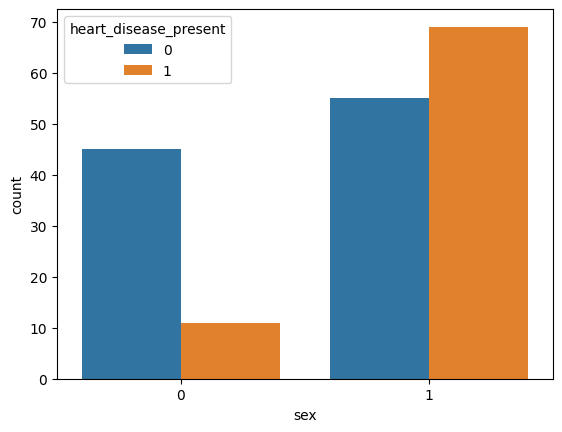

In [52]:
# Heart disease by gender

sns.countplot(x='sex', hue='heart_disease_present', data=df)
plt.show()

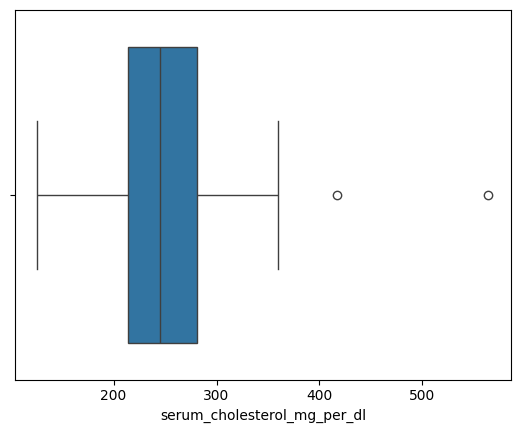

In [53]:
# Boxplot from outlier detection

sns.boxplot(x=df['serum_cholesterol_mg_per_dl'])
plt.show()

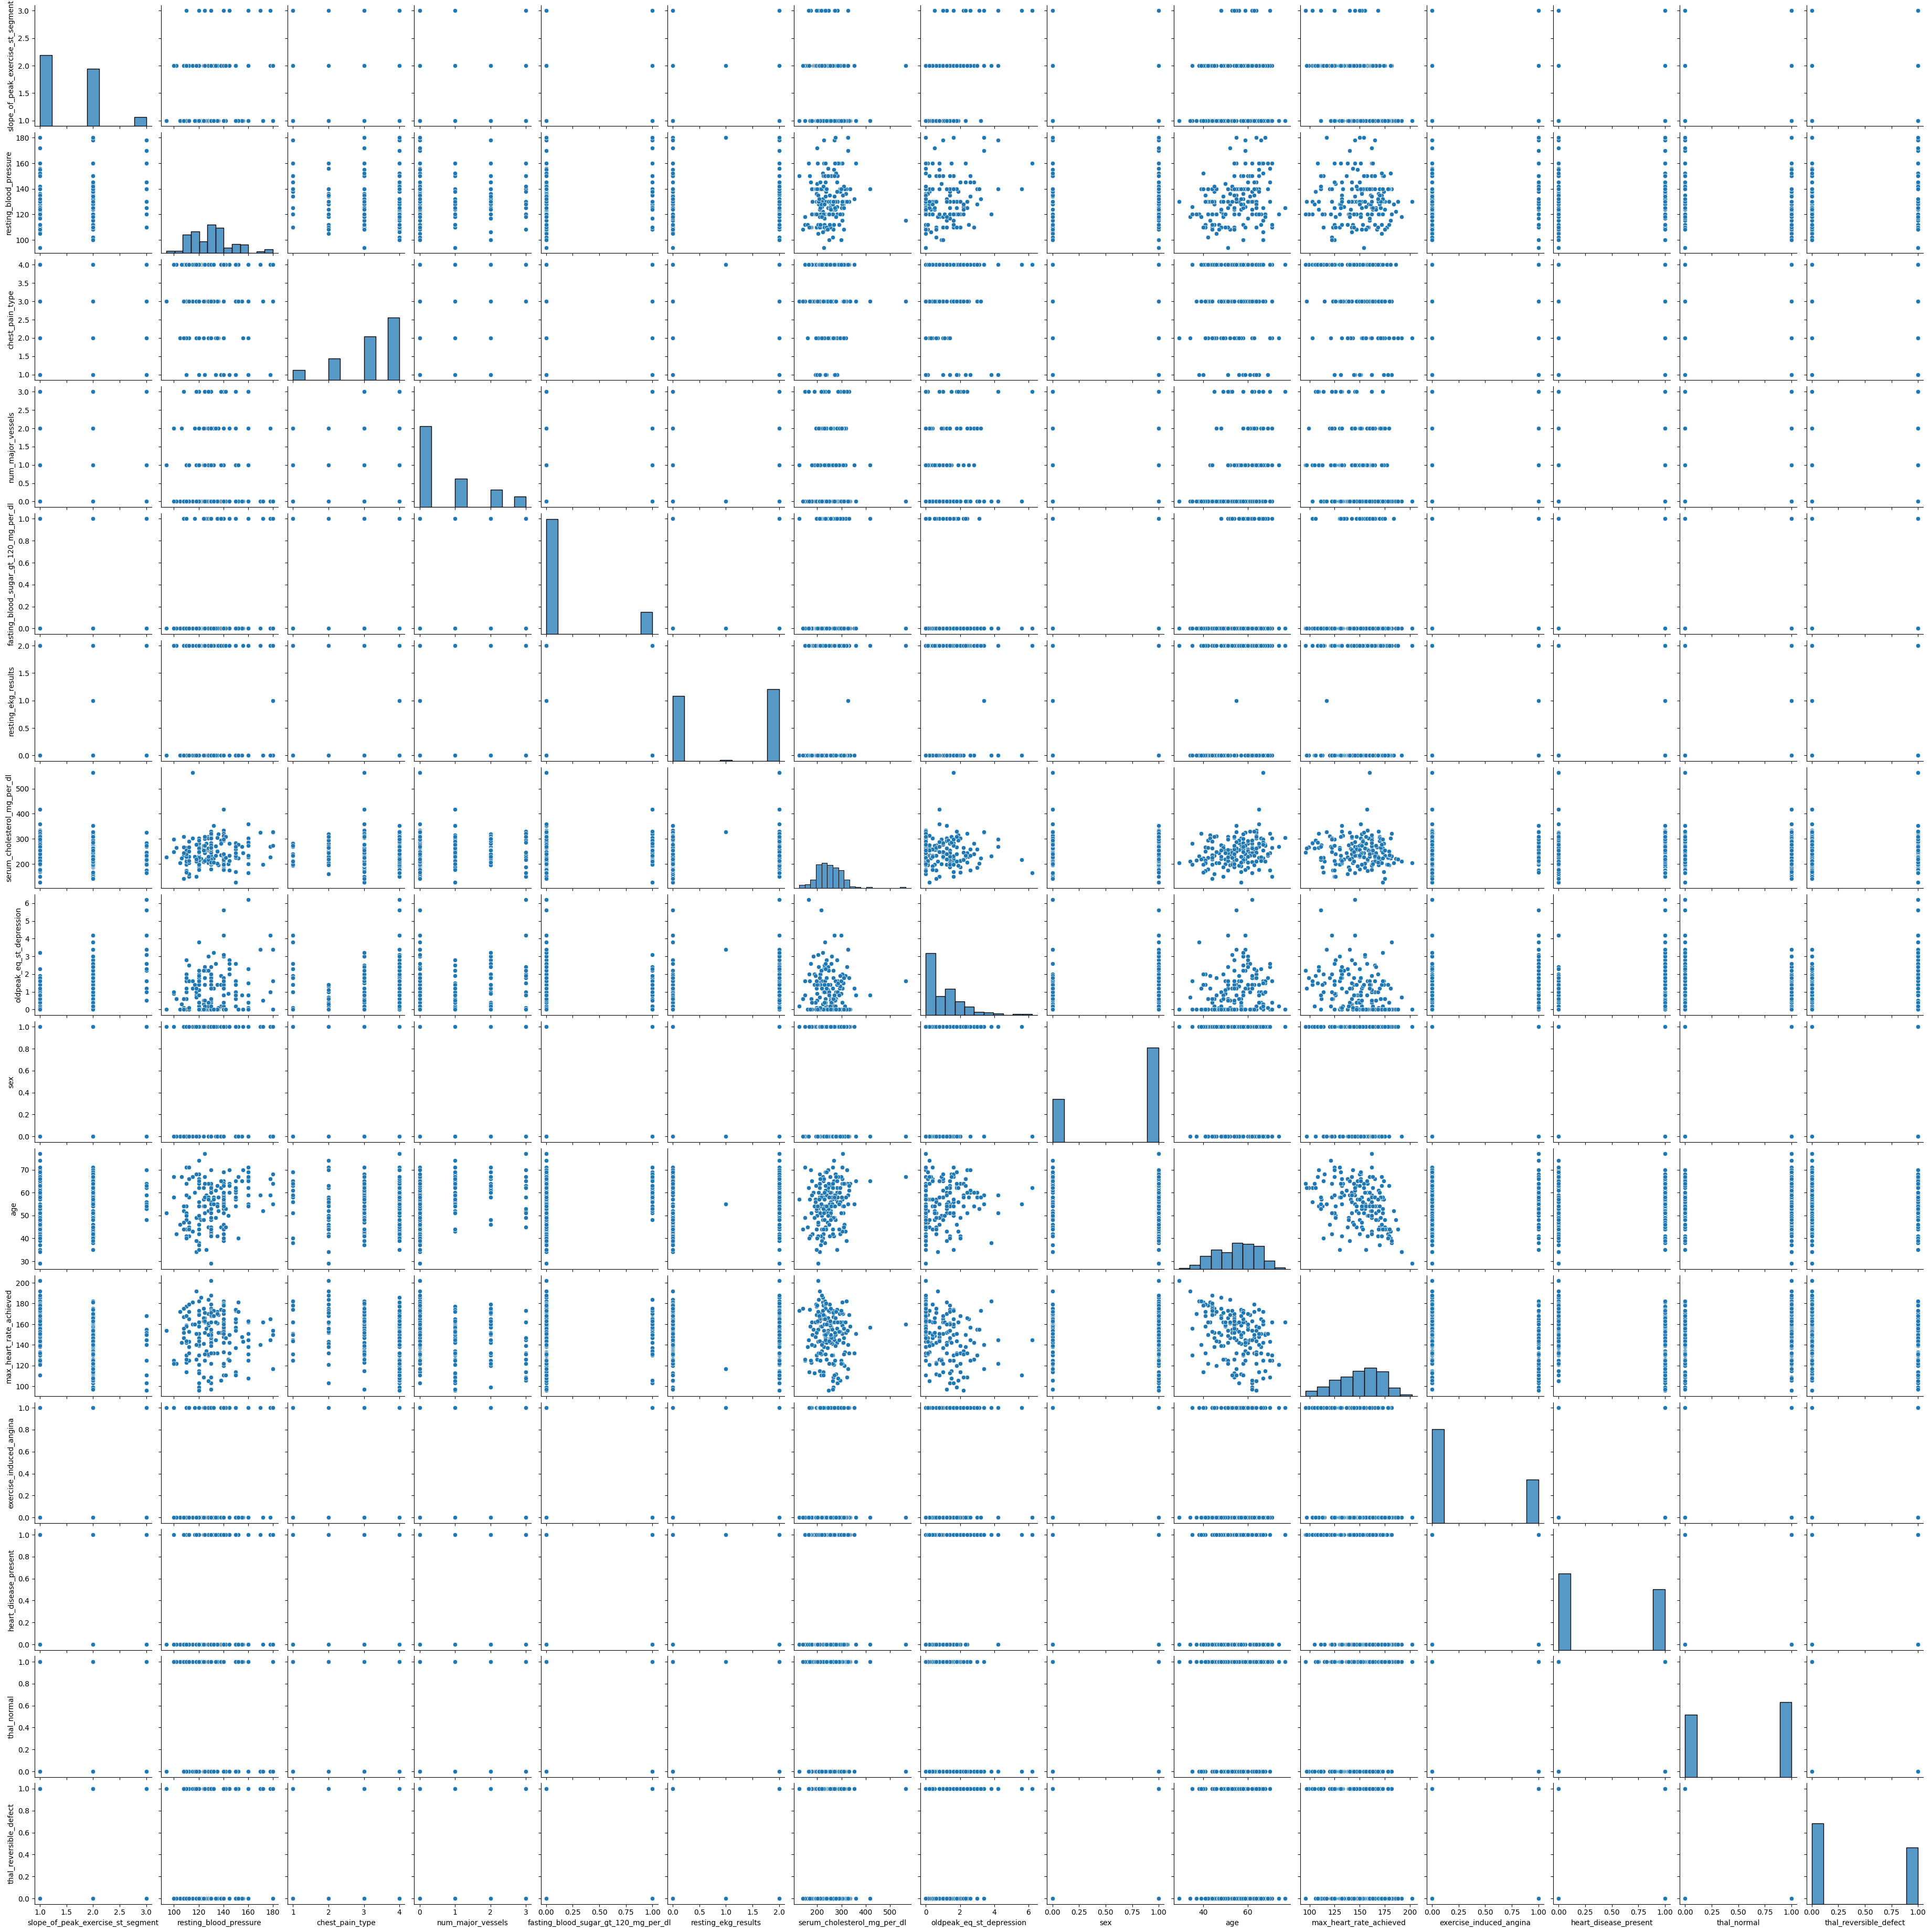

In [54]:
# Pairplot

sns.pairplot(df)
plt.show()

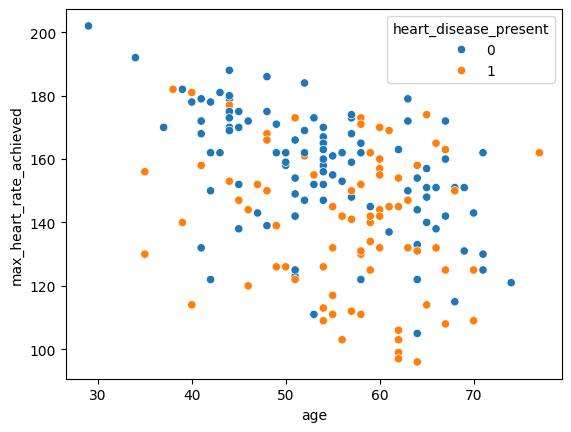

In [55]:
# Scatter plot

sns.scatterplot(
    x='age',
    y='max_heart_rate_achieved',
    hue='heart_disease_present',
    data=df
)

plt.show()

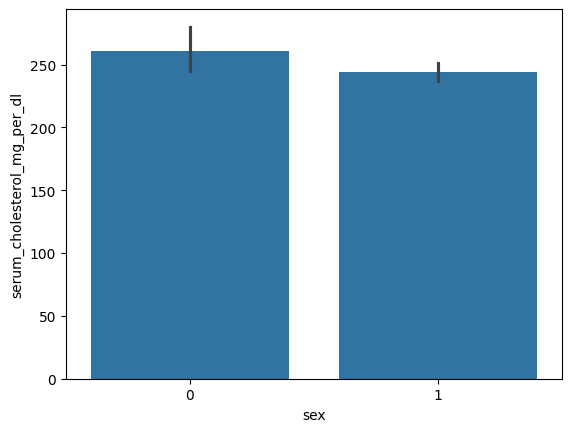

In [56]:
#Bar plot

sns.barplot(
    x='sex',
    y='serum_cholesterol_mg_per_dl',
    data=df
)

plt.show()

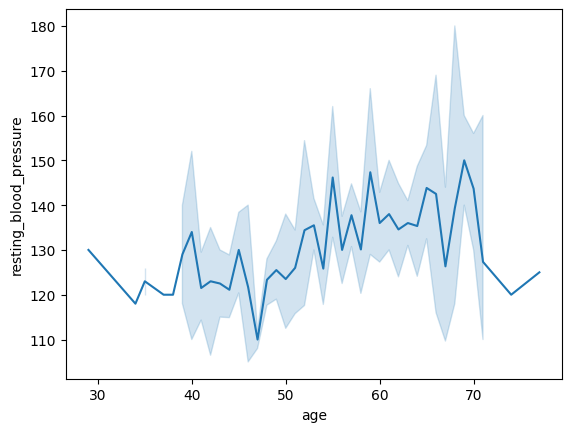

In [57]:
# Line plot

sns.lineplot(
    x='age',
    y='resting_blood_pressure',
    data=df
)

plt.show()

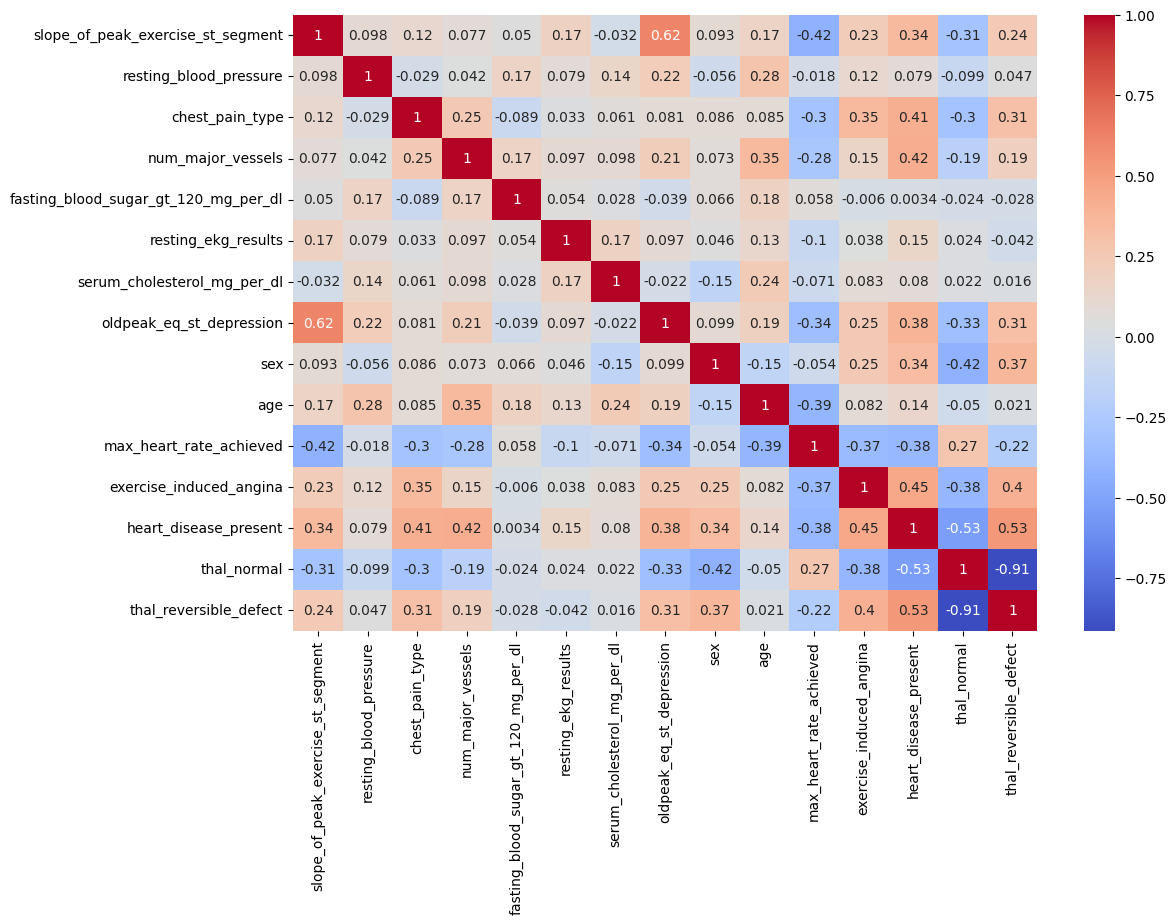

In [58]:
# Correlation matrics

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Step.4 Model building
In this step, the machine learning model is trained using the preprocessed dataset to predict whether a patient has heart disease or not.
For this project, Logistic Regression is used because it is suitable for binary classification problems and provides good prediction performance.

In [59]:
# Seperate independent and dependent variable

X=df.drop('heart_disease_present', axis=1)
y=df['heart_disease_present']

In [60]:
# Split dataset into Training and Testing data

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
# Feature scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [62]:
# Import Logistic regression

from sklearn.linear_model import LogisticRegression

In [63]:
# Create model

model = LogisticRegression()

In [64]:
# Train model

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [65]:
# Predict test data

y_pred = model.predict(X_test)

# Step. 5 Model evaluation
In this step, the performance of the Logistic Regression model is evaluated using different evaluation metrics.
These metrics help measure the accuracy and prediction capability of the model on test data.

In [68]:
# Import evaluation metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [69]:
# Accuracy score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8333333333333334


In [70]:
# Confusion matrics

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[15  1]
 [ 5 15]]


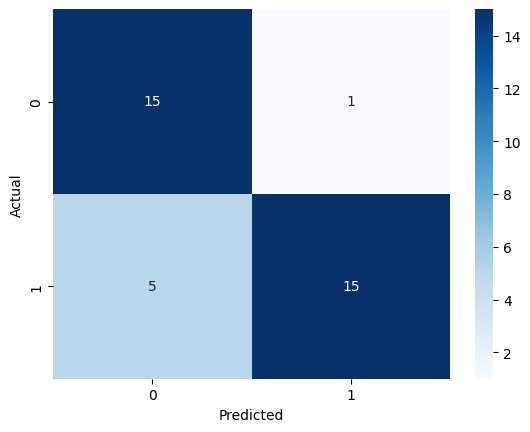

In [71]:
# Confusion matrics visualization

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [72]:
# Classification report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36



In [73]:
#Training sccore

train_score = model.score(X_train, y_train)

print("Training Score:", train_score)

Training Score: 0.8541666666666666


In [74]:
# Testing score

test_score = model.score(X_test, y_test)

print("Testing Score:", test_score)

Testing Score: 0.8333333333333334


# review :-
Metric	         | Score
-----------------|------
Training Score	 |85.41%
Testing Score	 |83.33%

This indicates that:

the model is learning properly,
testing accuracy is also good,
and there is no major overfitting issue because both scores are close.

# 2. Decision Tree Model


In [83]:

from sklearn.tree import DecisionTreeClassifier

In [78]:
# Create model
dt_model = DecisionTreeClassifier()

In [79]:
# Train model

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [81]:
# prediction
dt_pred = dt_model.predict(X_test)

In [82]:
#Accuracy
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8055555555555556


# 3. Random Forest Model


In [84]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
# create model

rf_model = RandomForestClassifier()

In [86]:
# train model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [87]:
#prediction
rf_pred = rf_model.predict(X_test)

In [88]:
# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8055555555555556


In [89]:
lr_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8333333333333334


In [91]:
# Model comparision 

comparison = pd.DataFrame({ 'Model': ['Logistic Regression','Decision Tree','Random Forest'],
                            'Accuracy': [lr_accuracy,dt_accuracy,rf_accuracy]})


In [92]:
comparison

,Model,Accuracy
0,Logistic Regression,0.833333
1,Decision Tree,0.805556
2,Random Forest,0.805556


# Conclusion

Among all the machine learning models, Logistic Regression achieved the highest accuracy of 83.33%. It also provided balanced training and testing 
performance. Therefore, Logistic Regression is selected as the best model for heart disease prediction in this project.

# Report on Challenges Faced

### Challenges Faced
1. Understanding and merging two different datasets (values.csv and labels.csv) using patient_id.
2. Handling categorical data such as the thal column because machine learning models cannot directly work with text values.
3. Understanding medical feature names and their meanings.
4. Performing proper preprocessing and visualization for better model performance.
5. Avoiding overfitting by comparing training and testing accuracy.

### Techniques Used
1. Used pd.merge() to combine both datasets using patient_id.
2. Used pd.get_dummies() to convert categorical columns into numerical format.
3. Used EDA techniques such as heatmaps, histograms, boxplots, and scatter plots for data understanding.
4. Used train-test split and feature scaling for proper model training.
5. Applied Logistic Regression for binary classification prediction.

Task 3 :-
#### Suggestions to the Hospital
1. Conduct regular heart health checkups for patients, especially for older adults and high-risk individuals.
2. Monitor important health factors such as blood pressure, cholesterol level, heart rate, and blood sugar regularly.
3. Encourage patients to maintain a healthy lifestyle including proper diet, regular exercise, and stress management.
4. Use machine learning prediction systems to identify high-risk patients at an early stage.
5. Create awareness programs about heart disease prevention and healthy living.
6. Maintain digital healthcare records for better monitoring and faster diagnosis.
7. Advise patients to avoid smoking, alcohol, and unhealthy food habits to reduce heart disease risk.